# Preface
The main goal of this notebook is to explore temporal and spatial patters to assess which crimes categories exhibit stable struture and which ones are created from noise. The focus is on finding structure in these crimes.



In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os, subprocess

# if not os.path.exists('/content/DataGuard'):
#     subprocess.run([
#         'git', 'clone',
#         'https://github.com/Andria-colab/DataGuard.git',
#         '/content/DataGuard'
#     ], check=True)


First load dataset to look up given information for help in plotting process.

In [10]:
data = pd.read_csv('../data/crime_data_clean.csv')

data.head()

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Latitude,Longitude,Location,Hour,Day_of_Week,Month,Is_Weekend,Season,Area_Hour_Crime_Count,Area_Season_Crime_Count
0,10365064,HZ100370,2015-12-31 23:59:00,075XX S EMERALD AVE,1320,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,...,41.757367,-87.642993,POINT (-87.642992854 41.757366519),23,3,12,0,Winter,351,1416
1,10364662,HZ100006,2015-12-31 23:55:00,079XX S STONY ISLAND AVE,0430,BATTERY,AGGRAVATED: OTHER DANG WEAPON,STREET,False,False,...,41.751270,-87.585822,POINT (-87.585822373 41.751270452),23,3,12,0,Winter,53,303
2,10364740,HZ100010,2015-12-31 23:50:00,024XX W FARGO AVE,0820,THEFT,$500 AND UNDER,APARTMENT,False,False,...,42.016804,-87.690709,POINT (-87.690708662 42.016804165),23,3,12,0,Winter,131,728
3,10364683,HZ100002,2015-12-31 23:50:00,037XX N CLARK ST,0460,BATTERY,SIMPLE,SIDEWALK,True,False,...,41.949837,-87.658635,POINT (-87.658635101 41.949837364),23,3,12,0,Winter,255,1084
4,10366580,HZ102701,2015-12-31 23:45:00,050XX W CONCORD PL,1310,CRIMINAL DAMAGE,TO PROPERTY,APARTMENT,False,False,...,41.910470,-87.751597,POINT (-87.751597381 41.910469677),23,3,12,0,Winter,767,3708


My initial guess is to start from the big picture, get a total understanding and then go down into meaningful details.

Let's start challenging the traditional views on how, where and when do crimes happen to avoid personal biases throughot the project. 

In [11]:
stats_cols = ['Hour', 'Month', 'Area_Hour_Crime_Count', 'Area_Season_Crime_Count']
desc_stats = data[stats_cols].describe().T
desc_stats['variance'] = data[stats_cols].var()
print("--- Descriptive Statistics ---")
print(desc_stats[['mean', '50%', 'std', 'variance', '25%', '75%']])

--- Descriptive Statistics ---
                                mean     50%         std       variance  \
Hour                       13.301883    14.0    6.595156      43.496088   
Month                       6.593998     7.0    3.340280      11.157471   
Area_Hour_Crime_Count     276.764610   236.0  205.428550   42200.889070   
Area_Season_Crime_Count  1460.945875  1374.0  977.664621  955828.111168   

                           25%     75%  
Hour                       9.0    19.0  
Month                      4.0     9.0  
Area_Hour_Crime_Count    121.0   378.0  
Area_Season_Crime_Count  728.0  1981.0  


According to the output average crime time is at 13.3 o'clock with median 14, meaning that crime activity is centered around the early afternoon, but simply speaking half of the crimes happen before 2 o'clock and other half after.

The next guess it to connect time periods with crimes themselves, but first we need to analyze crime type frequencies separately from time periods.

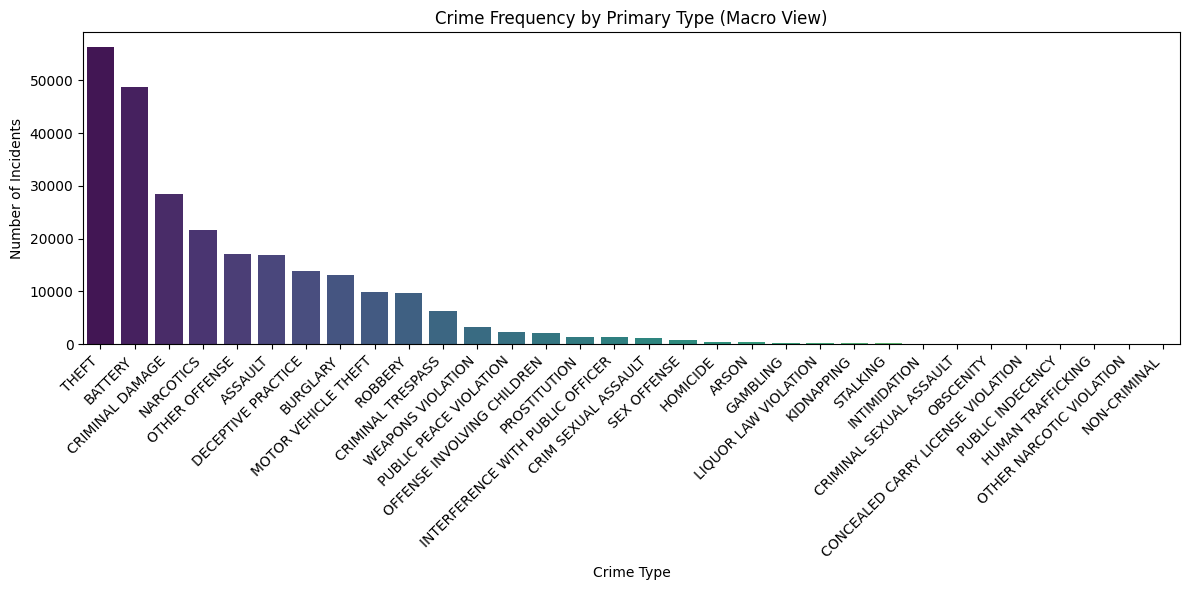

In [12]:
plt.figure(figsize=(12, 6))
crime_counts = data['Primary Type'].value_counts()

sns.barplot(
    x=crime_counts.index,
    y=crime_counts.values,
    hue=crime_counts.index,
    palette='viridis',
    legend=False
)

plt.title('Crime Frequency by Primary Type (Macro View)')
plt.xlabel('Crime Type')
plt.ylabel('Number of Incidents')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()


The crime frequency bar chart showed most frequent crimes, from which 6 were chosen for further analysis. These are: theft, battery, criminal damage, narcotics, other offenses.

The rest were will be taken into consideration due to multiple reasons.

 - A small number of crime types make up most of the reported incidents. Focusing on these lets us analyze patterns that matter for the majority of cases, instead of being distracted by rare and noisy events.
 - Many low-frequency crime types occur too rarely to reveal stable patters. Including them would introduce noise and make observed trends harder to interpret.
 - Choosing only small number of crime types allows us to make analysis more understandable, oriented on a better idea and avoids overcrowding.

Next step is to connnect crimes with time, as I have already mentioned, we will work from top, seasons, to smaller time periods.

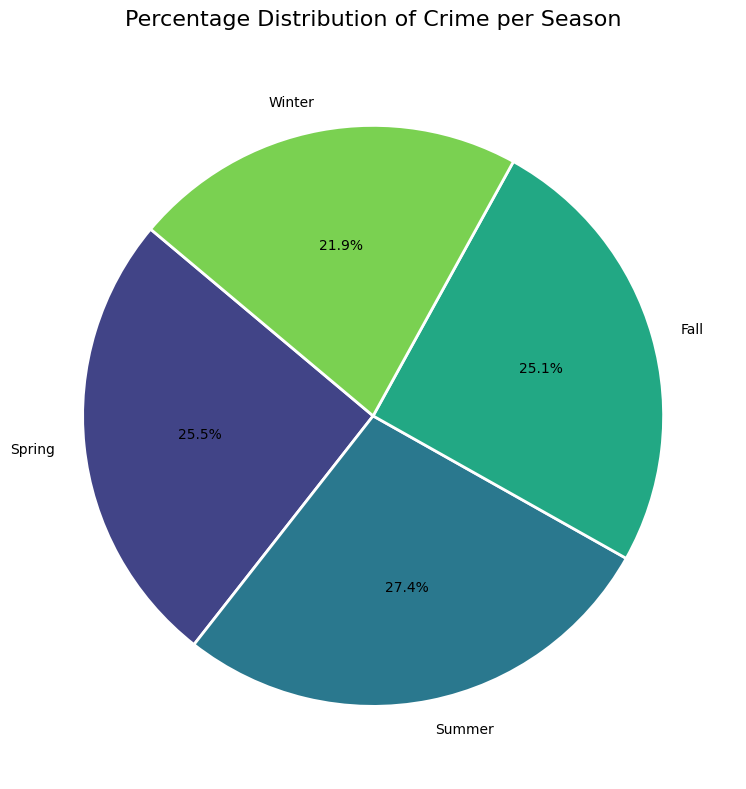

In [13]:
seasonal_order = ['Spring', 'Summer', 'Fall', 'Winter']
season_counts = data['Season'].value_counts().reindex(seasonal_order)

plt.figure(figsize=(10, 8))
plt.pie(
    season_counts, 
    labels=season_counts.index, 
    autopct='%1.1f%%',           
    startangle=140,              
    colors=sns.color_palette('viridis', len(seasonal_order)), 
    wedgeprops={'edgecolor': 'white', 'linewidth': 2} 
)

plt.title('Percentage Distribution of Crime per Season', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

According to this plot, we see most of the crimes happen in summer, almost equal in fall and spring, the least in winter.

It is interesting to see which crimes conctribute how to these season distribution.

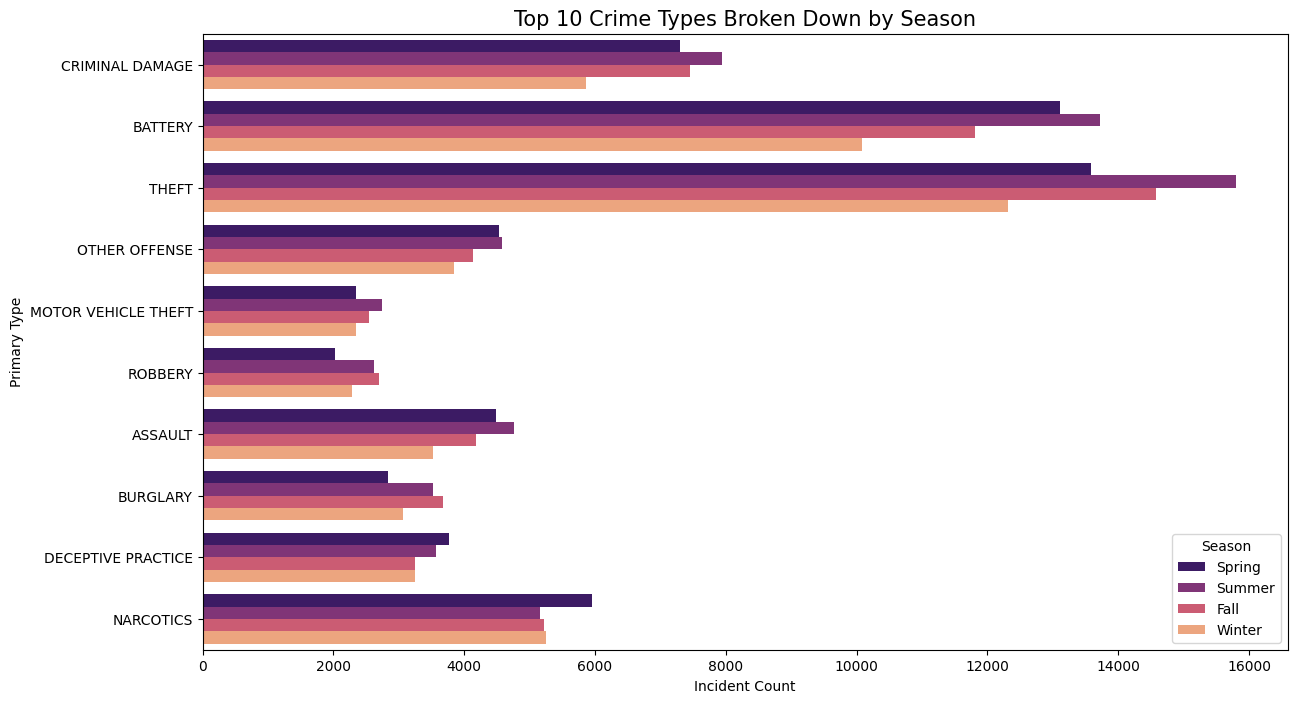

In [14]:
top_10_crimes = data['Primary Type'].value_counts().nlargest(10).index
data_top10 = data[data['Primary Type'].isin(top_10_crimes)]

plt.figure(figsize=(14, 8))
sns.countplot(data=data_top10, y='Primary Type', hue='Season',
              hue_order=seasonal_order, palette='magma')
plt.title('Top 10 Crime Types Broken Down by Season', fontsize=15)
plt.xlabel('Incident Count')
plt.legend(title='Season', loc='lower right')
plt.show()

Most of the crimes mostly happen in summer, but some crimes still ruin this trend, most of which stay stable throughout the year, but there is an outlier, Narcotics to be more precise, which dominates by ~1000 in spring, which could point at something meaningful. We can see theft is overall most dominant crime.

More stable crime is deceptive practice, which has little to no change. This suggests that the crime is not strongly influenced by weather or outdoor activity and is therefore structurally different from top crimes, thus we do not pursue any further analysis.   

My next thought is to try to find why these criminal activities depend on seasons, maybe holiday periods, or daylight hours.

But first, lets try to find why narcotics in spring dominates other seasons.  

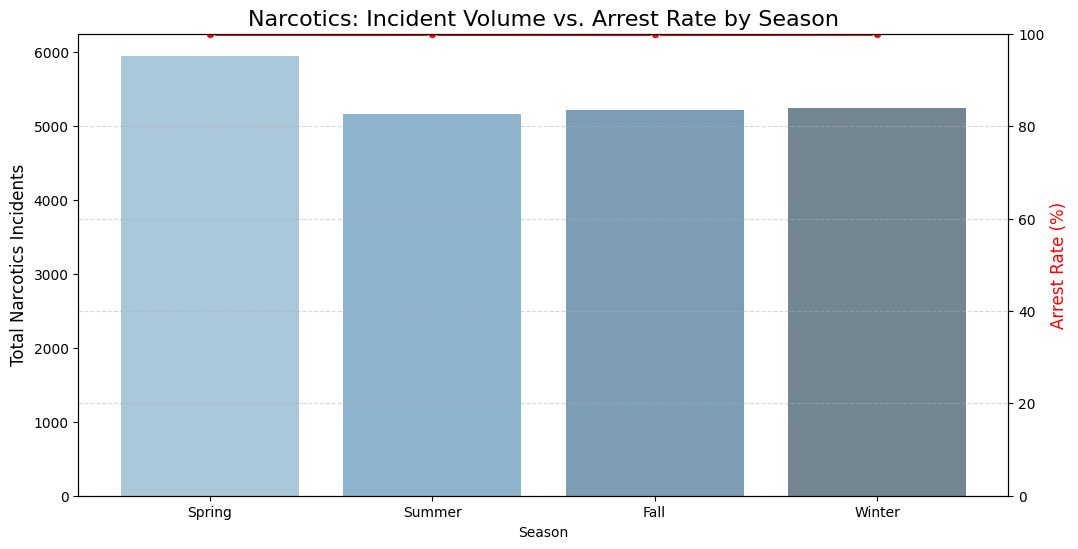

In [15]:
narcotics_data = data[data['Primary Type'] == 'NARCOTICS']

arrest_counts = (
    narcotics_data
    .groupby(['Season', 'Arrest'])
    .size()
    .unstack(fill_value=0)
)

arrest_counts['Total'] = arrest_counts[True] + arrest_counts[False]
arrest_counts['Arrest Rate (%)'] = (
    arrest_counts[True] / arrest_counts['Total']
) * 100

seasons_order = ['Spring', 'Summer', 'Fall', 'Winter']
arrest_counts = arrest_counts.reindex(seasons_order)

fig, ax1 = plt.subplots(figsize=(12, 6))

sns.barplot(
    x=arrest_counts.index,
    y=arrest_counts['Total'],
    hue=arrest_counts.index,
    palette='Blues_d',
    legend=False,
    alpha=0.7,
    ax=ax1
)

ax1.set_ylabel('Total Narcotics Incidents', fontsize=12)
ax1.set_title('Narcotics: Incident Volume vs. Arrest Rate by Season', fontsize=16)

ax2 = ax1.twinx()
sns.lineplot(
    x=arrest_counts.index,
    y=arrest_counts['Arrest Rate (%)'],
    ax=ax2,
    color='red',
    marker='o',
    linewidth=3
)

ax2.set_ylabel('Arrest Rate (%)', color='red', fontsize=12)
ax2.set_ylim(0, 100)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()




There is a really interesting part to think about here, when it comes to narcotics, legally there is no victim, the crime only "happened" according to our data, because the police found them, which is backed by this results

To support this claim, I will try to plot correlation between narcotics incidents and arrests.

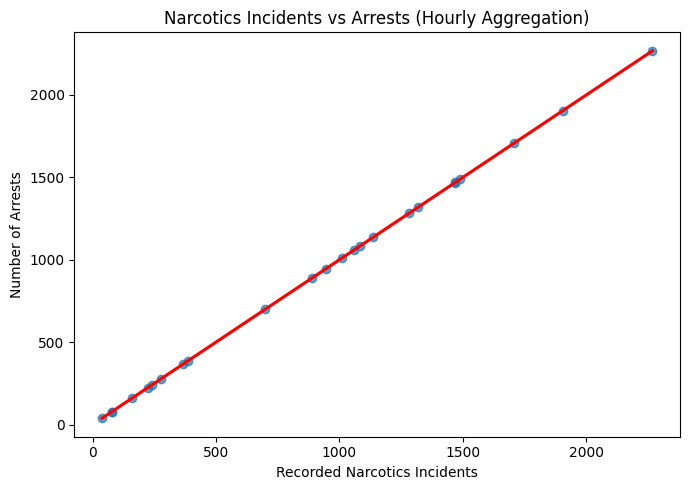

In [16]:
narc = data[data["Primary Type"] == "NARCOTICS"]

agg = (
    narc
    .groupby("Hour")
    .agg(
        incidents=("Primary Type", "count"),
        arrests=("Arrest", "sum")
    )
    .reset_index()
)

plt.figure(figsize=(7, 5))
sns.regplot(
    data=agg,
    x="incidents",
    y="arrests",
    scatter_kws={"alpha": 0.7},
    line_kws={"color": "red"}
)

plt.title("Narcotics Incidents vs Arrests (Hourly Aggregation)")
plt.xlabel("Recorded Narcotics Incidents")
plt.ylabel("Number of Arrests")
plt.tight_layout()
plt.show()

The scatter plots shows strong lenear relationship between arrests made and narcotics. This proves the point, that crimes about narcotics enter in the dataset almost always when police action occurs, rather just some criminal activity. Thus, the data only captrues police behavoir more than crime patters.

Next guess is to take more unstable crimes, unlike deceptive practice, and try to connect them with locations to get more context.

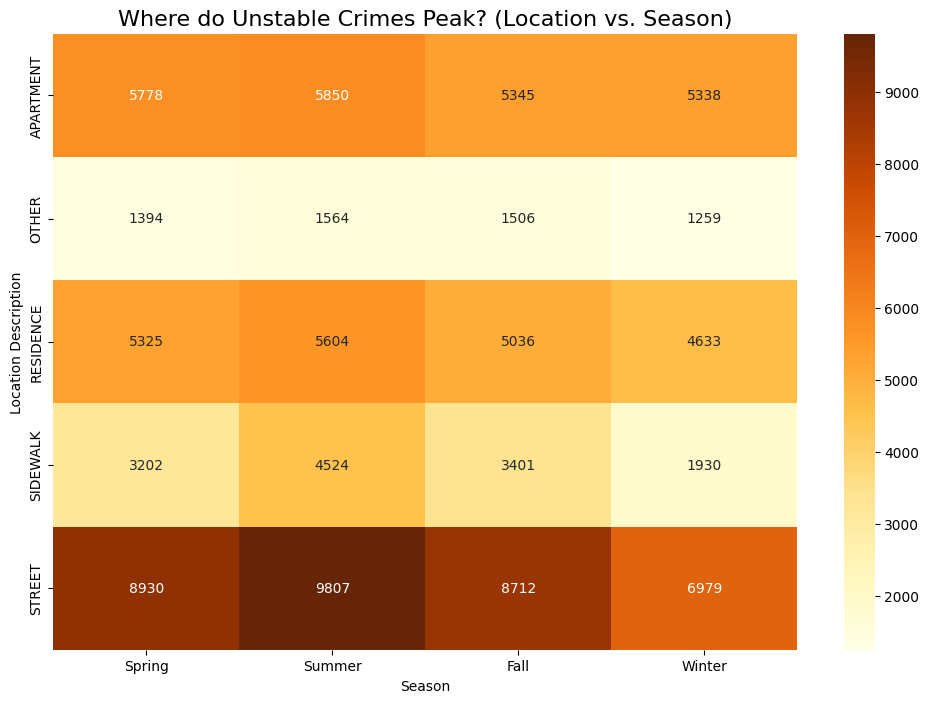

In [17]:
unstable_crimes = ['BATTERY', 'THEFT', 'ASSAULT', 'CRIMINAL DAMAGE']
data_unstable = data[data['Primary Type'].isin(unstable_crimes)]

top_locations = data_unstable['Location Description'].value_counts().nlargest(5).index
df_loc = data_unstable[data_unstable['Location Description'].isin(top_locations)]

loc_pivot = pd.crosstab(df_loc['Location Description'], df_loc['Season'])[['Spring', 'Summer', 'Fall', 'Winter']]

plt.figure(figsize=(12, 8))
sns.heatmap(loc_pivot, annot=True, fmt="d", cmap="YlOrBr")
plt.title('Where do Unstable Crimes Peak? (Location vs. Season)', fontsize=16)
plt.show()

Based on the matrix given above, the huge increase in street crimes from winter to summer, could suggest that warmer weather or day time increasing could be the driven factor for crimes in summer.   

Crimes that happened in the apartments stay relatively stable, with only small falctuation.  

Let's get into more details and check distribution of crime time by location.

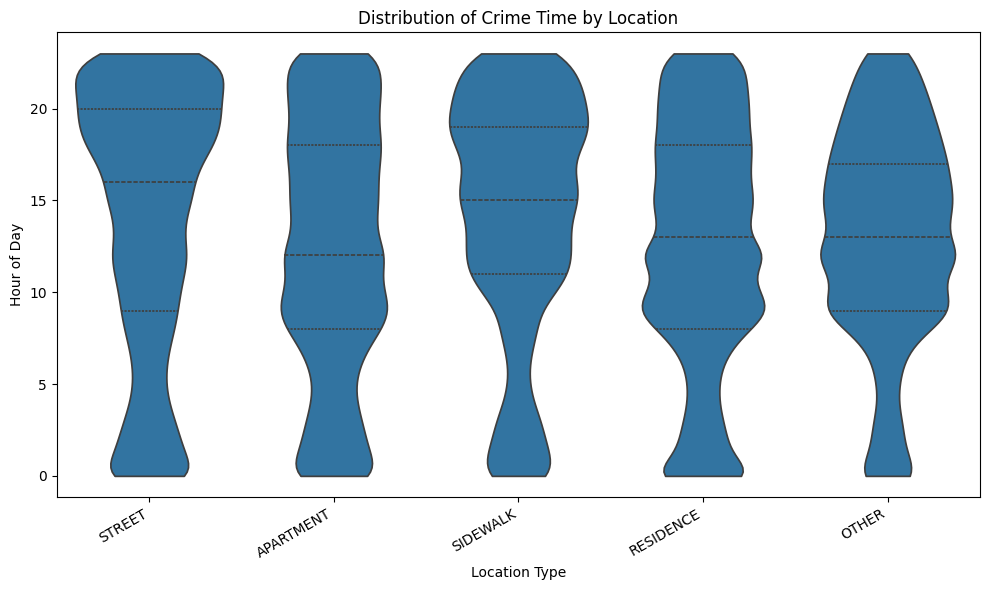

In [18]:
top_locations = (
    data["Location Description"]
    .value_counts()
    .head(5)
    .index
)

subset = data[data["Location Description"].isin(top_locations)]

plt.figure(figsize=(10, 6))
sns.violinplot(
    data=subset,
    x="Location Description",
    y="Hour",
    inner="quartile",
    cut=0
)

plt.title("Distribution of Crime Time by Location")
plt.xlabel("Location Type")
plt.ylabel("Hour of Day")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

We see streets have very wide distribution, especially in the late afternoon. Thus, as more people are outside and the darkness arises, crime in the streets raises.
    
Apartment crimes are more constrained by daily routines. 

Sidewalk crimes appear less structured.

Residential crimes are less tied to public activities compared to the apartment crimes. 

Other places for crimes are more noisy, because it contains multiple places where the crime happens.

These analysis shows that time as a predictive feature stongly depends on the location. 


Lets try to examine influence of day light on the crimes.

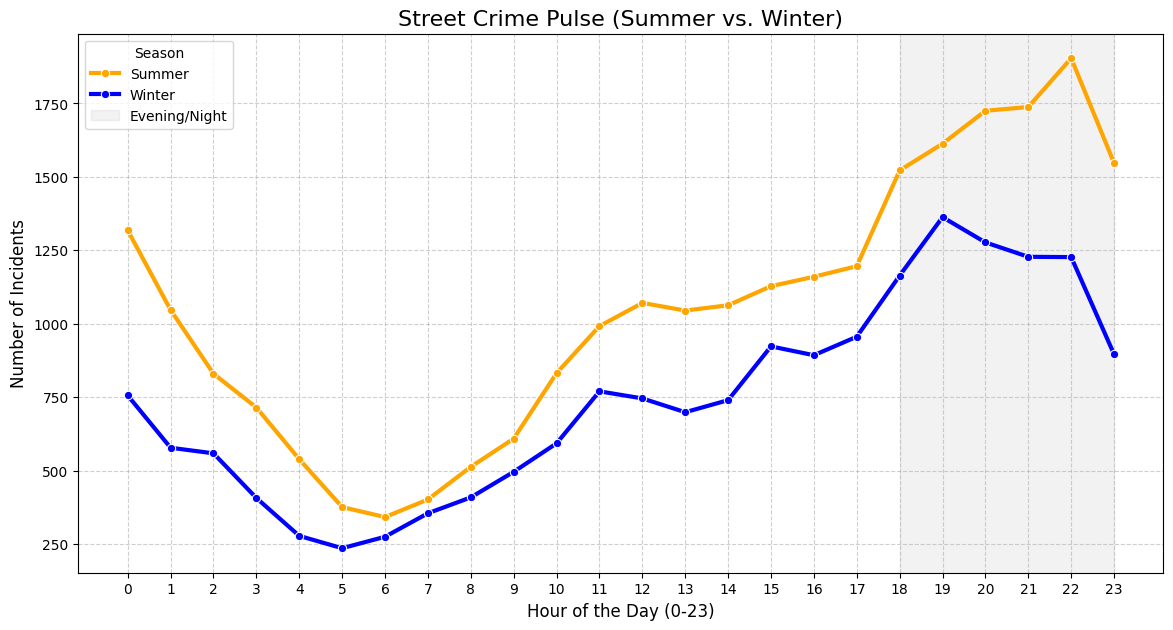

In [19]:
outdoor_locations = ['STREET', 'SIDEWALK']
data_street = data[data['Location Description'].isin(outdoor_locations)]

data_compare = data_street[data_street['Season'].isin(['Summer', 'Winter'])]

hourly_pulse = data_compare.groupby(['Hour', 'Season']).size().reset_index(name='Crime Count')

plt.figure(figsize=(14, 7))
sns.lineplot(data=hourly_pulse, x='Hour', y='Crime Count', hue='Season',
             palette={'Summer': 'orange', 'Winter': 'blue'}, linewidth=3, marker='o')

plt.title('Street Crime Pulse (Summer vs. Winter)', fontsize=16)
plt.xlabel('Hour of the Day (0-23)', fontsize=12)
plt.ylabel('Number of Incidents', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.6)
plt.axvspan(18, 23, color='gray', alpha=0.1, label='Evening/Night')

plt.legend(title='Season')
plt.show()

This observation gave us nothing, as both lines are highly correlated.

So we will dive deeper to see based on day time periods how many arrests are made.

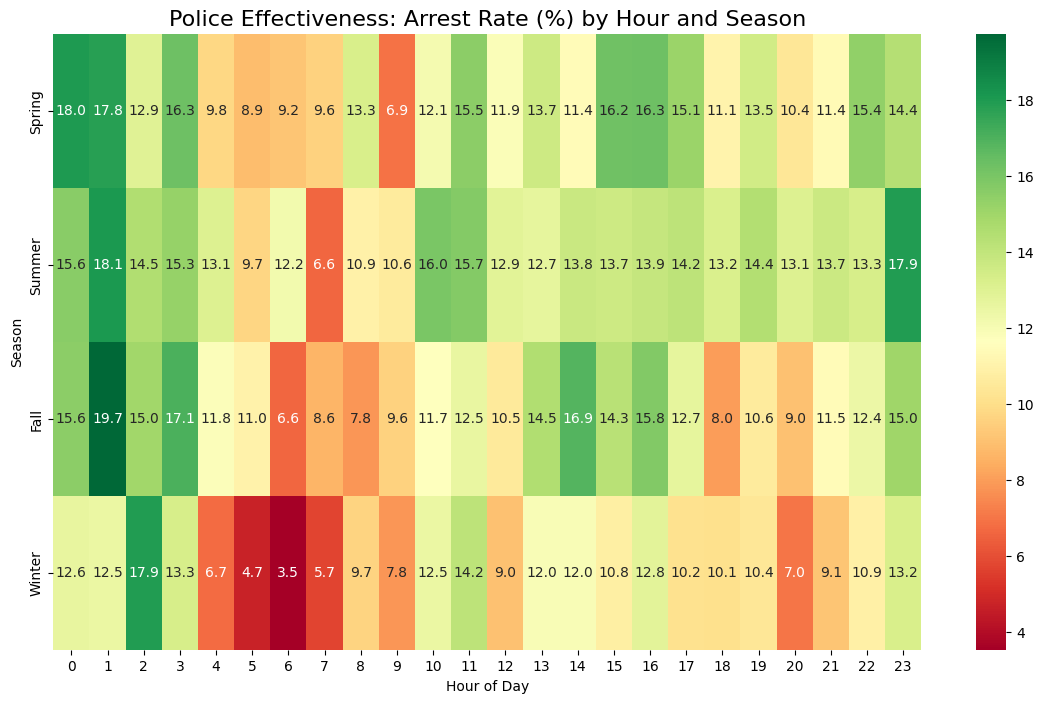

In [20]:
unstable_street = data[(data['Primary Type'].isin(['BATTERY', 'ASSAULT', 'THEFT'])) &
                       (data['Location Description'].isin(['STREET', 'SIDEWALK']))]

arrest_pivot = unstable_street.groupby(['Hour', 'Season'])['Arrest'].mean().unstack() * 100
arrest_pivot = arrest_pivot[['Spring', 'Summer', 'Fall', 'Winter']]

plt.figure(figsize=(14, 8))
sns.heatmap(arrest_pivot.T, cmap='RdYlGn', annot=True, fmt=".1f")
plt.title('Police Effectiveness: Arrest Rate (%) by Hour and Season', fontsize=16)
plt.xlabel('Hour of Day')
plt.ylabel('Season')
plt.show()

 The heatmap shows more Red in Winter, meaning that even though fewer crimes happen, the police catch a smaller percentage of those criminals compared to the Summer. This could suggest that bad weather and darkness make it easier for criminals to get away.

Before I move to any further and coplex feature analysis we have to feagure out in which direction to advance.

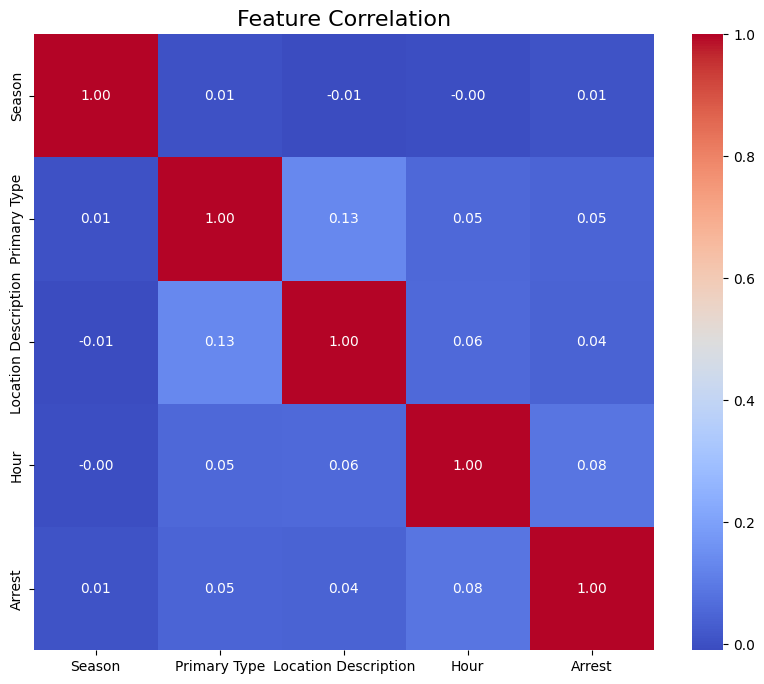

In [21]:
data_numeric = data[['Season', 'Primary Type', 'Location Description', 'Hour', 'Arrest']].copy()
for col in ['Season', 'Primary Type', 'Location Description']:
    data_numeric[col] = data_numeric[col].astype('category').cat.codes

corr = data_numeric.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation', fontsize=16)
plt.show()

Before anything we see very important fact, there is no simple linear relationship between the features. We see a big clue here, that crime predictability is conditional and each component by itself is very weak.

Nextly let us examine how related are location and time.

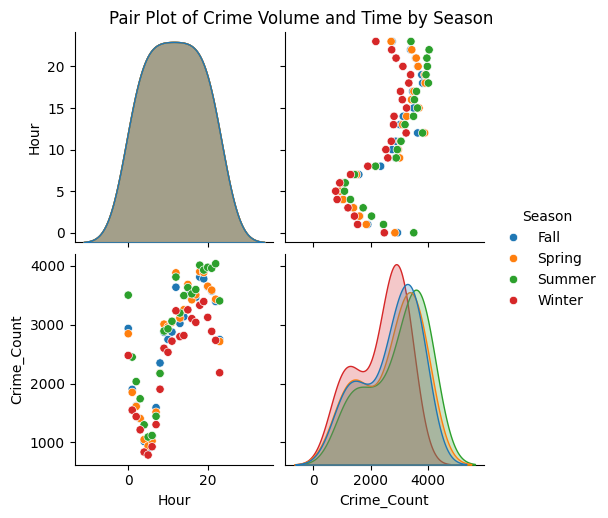

In [22]:
agg = (
    data
    .groupby(['Season', 'Hour'])
    .size()
    .reset_index(name='Crime_Count')
)

sns.pairplot(
    agg,
    vars=['Hour', 'Crime_Count'],
    hue='Season',
    diag_kind='kde'
)

plt.suptitle("Pair Plot of Crime Volume and Time by Season", y=1.02)
plt.show()

Crime volume rises towards the afternoon and starts dropping again in the evening, it follows a smooth daily pattern that looks nearly identical across seasons. Season changes only shifts the amount of crime, instead of the time. Lastly there is no simple hour formula that separates seasons.   

Before I move to any complex plots, let us consider checking last individual time based charactersitic, which is weekend vs weekday crimes.

<Figure size 1000x600 with 0 Axes>

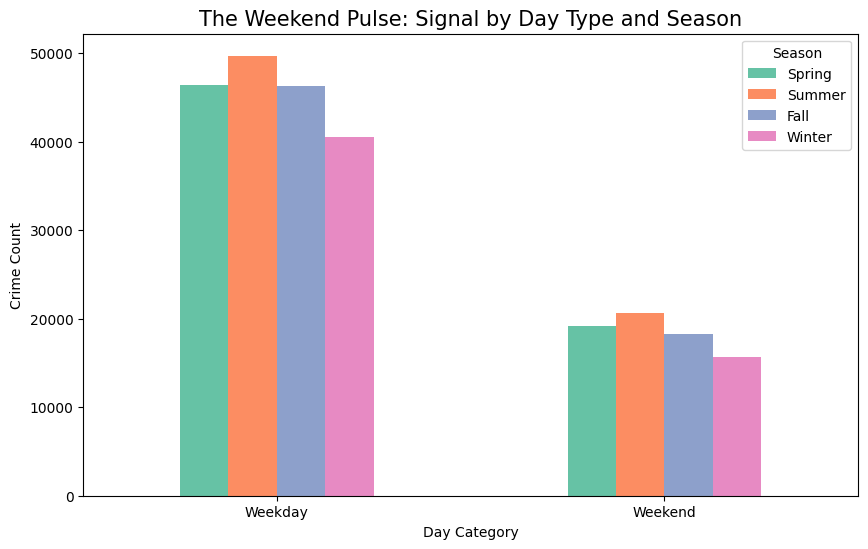

In [23]:
data['Day_Type'] = data['Is_Weekend'].map({1: 'Weekend', 0: 'Weekday'})

weekend_signal = data.groupby(['Day_Type', 'Season']).size().unstack()

seasons_order = ['Spring', 'Summer', 'Fall', 'Winter']
weekend_signal = weekend_signal[seasons_order]

plt.figure(figsize=(10, 6))
weekend_signal.plot(kind='bar', stacked=False, figsize=(10,6), color=['#66c2a5','#fc8d62','#8da0cb','#e78ac3'])
plt.title('The Weekend Pulse: Signal by Day Type and Season', fontsize=15)
plt.ylabel('Crime Count')
plt.xlabel('Day Category')
plt.xticks(rotation=0)
plt.legend(title='Season')
plt.show()

Instead of showing something interesting, this just proves my previosly stated point, because this difference in crimes closely mirrors the time fraction represented by these two periods. Thus, The time alone is not ideal in prediction of crime as we saw in previous plots.  

Looking at all crimes together can hide differences between crime types. Next, we look at each major crime type separately to see how their time patterns differ.

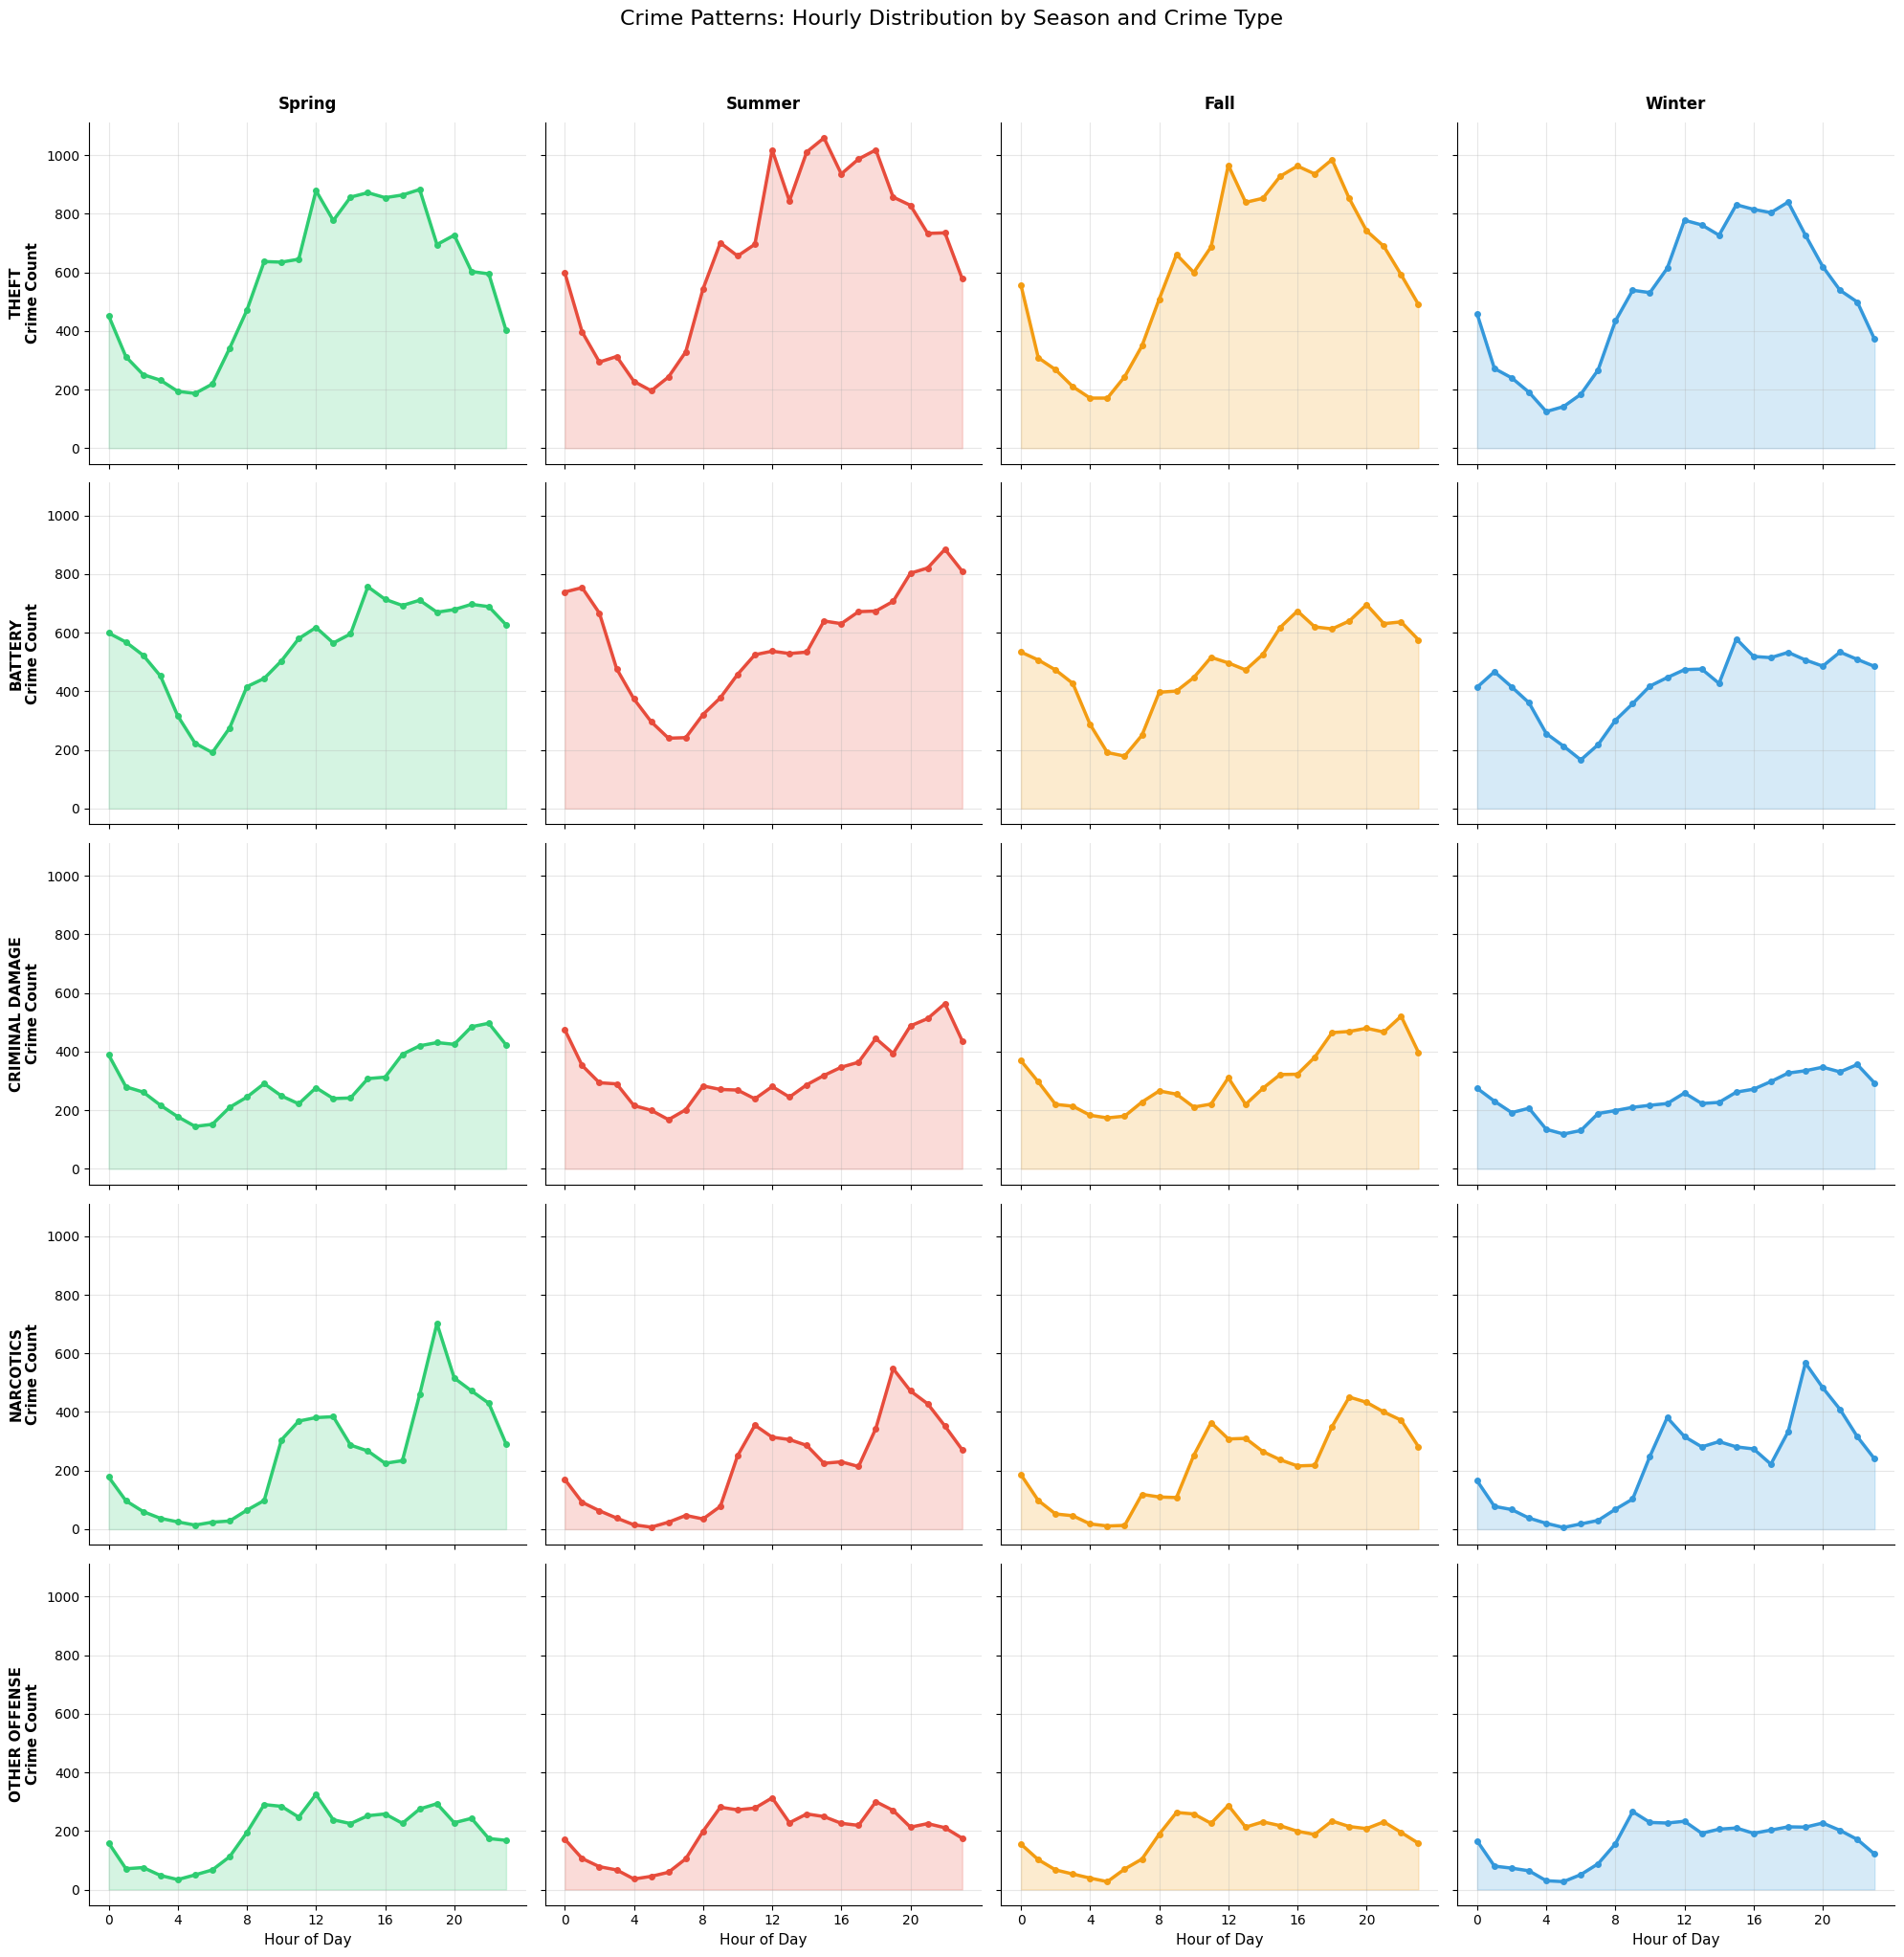

In [24]:

sns.set_palette("husl")


top_crimes = data['Primary Type'].value_counts().head(5).index.tolist()

df_top = data[data['Primary Type'].isin(top_crimes)]

hourly_seasonal = df_top.groupby(['Primary Type', 'Season', 'Hour']).size().reset_index(name='Crime_Count')

season_order = ['Spring', 'Summer', 'Fall', 'Winter']
hourly_seasonal['Season'] = pd.Categorical(hourly_seasonal['Season'], categories=season_order, ordered=True)

fig, axes = plt.subplots(len(top_crimes), 4, figsize=(20, 4*len(top_crimes)), sharey=True, sharex=True)
fig.suptitle('Crime Patterns: Hourly Distribution by Season and Crime Type', fontsize=16, y=1.02)

season_colors = {'Spring': '#2ecc71', 'Summer': '#e74c3c', 'Fall': '#f39c12', 'Winter': '#3498db'}

for i, crime_type in enumerate(top_crimes):
    for j, season in enumerate(season_order):
        ax = axes[i, j]

        crime_season_data = hourly_seasonal[
            (hourly_seasonal['Primary Type'] == crime_type) &
            (hourly_seasonal['Season'] == season)
        ]

        ax.plot(crime_season_data['Hour'], crime_season_data['Crime_Count'],
                color=season_colors[season], linewidth=2.5, marker='o', markersize=4)

        ax.fill_between(crime_season_data['Hour'], crime_season_data['Crime_Count'],
                        alpha=0.2, color=season_colors[season])

        if i == 0:
            ax.set_title(f'{season}', fontsize=12, pad=10, fontweight='bold')

        if j == 0:
            ax.set_ylabel(f'{crime_type}\nCrime Count', fontsize=11, fontweight='bold')
        else:
            ax.set_ylabel('')

        if i == len(top_crimes) - 1:
            ax.set_xlabel('Hour of Day', fontsize=11)

        ax.set_xticks(range(0, 24, 4))
        ax.set_xticklabels(range(0, 24, 4))

        ax.grid(True, alpha=0.3)

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


From these plots, we see some very clear patterns emerging. We see not all crimes follow the same "schedule".

Theft mostly happens in late afternoon, when people are mostly outside, coming back from work, or doing after work activities(haning out, dining out, shopping, etc.), whcih makes sense.

The battery doesnt show such clear pattern, but we can still interpret that, in spring and winter, it spikes around 3 pm, but at summer and fall, the peak shifts to late evening, about 8 to 10pm.

Criminal demage has the clearest pattern peaking at 10pm on every season.

Other crimes mostly shift to noon, except in winter they shift to 9 Am.

The expected result didn't dissapoint, the time of the day is great predictor for some crimes, knowing the season.

For our final plot, let's combine more trusted characteristics for prediction.

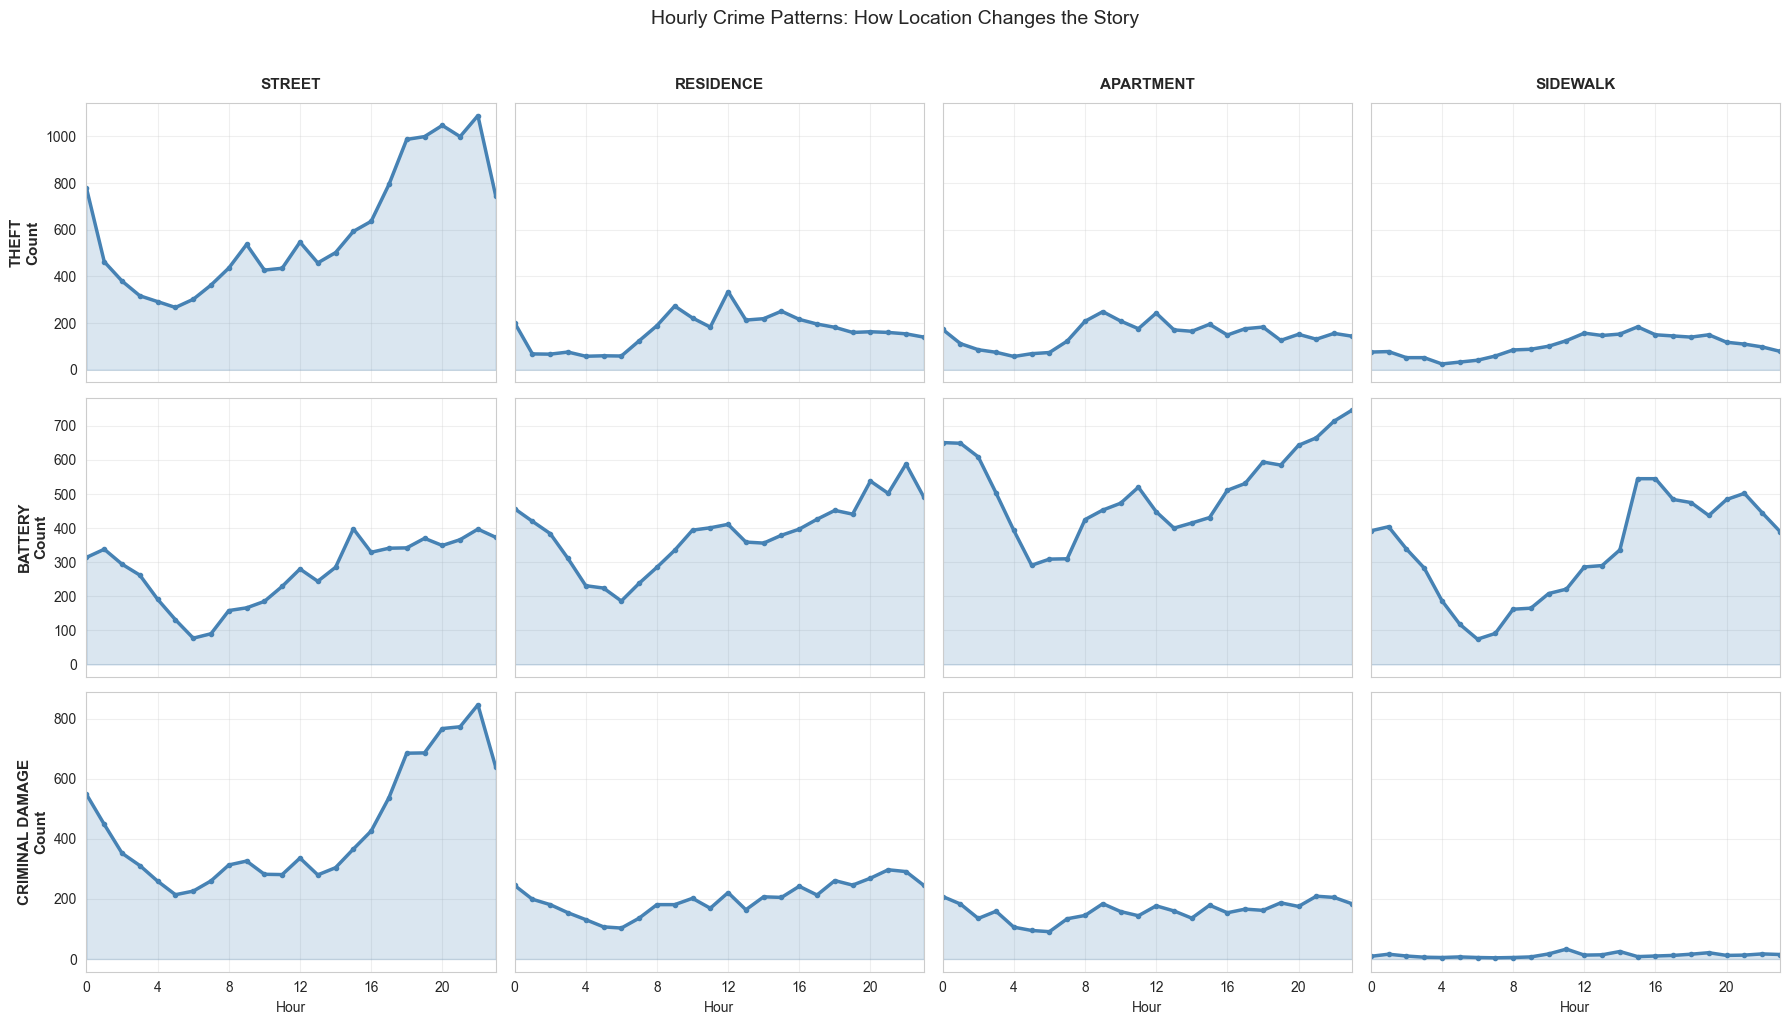

In [25]:
sns.set_style("whitegrid")
top_crimes = ['THEFT', 'BATTERY', 'CRIMINAL DAMAGE']
top_locations = data['Location Description'].value_counts().head(4).index.tolist()

filtered_data = data[
    data['Primary Type'].isin(top_crimes) &
    data['Location Description'].isin(top_locations)
]

location_hourly = filtered_data.groupby(
    ['Primary Type', 'Location Description', 'Hour']
).size().reset_index(name='Count')

fig, axes = plt.subplots(
    len(top_crimes),
    len(top_locations),
    figsize=(18, 10),
    sharex=True,
    sharey='row'
)

if len(top_crimes) == 1:
    axes = axes.reshape(1, -1)

for i, crime in enumerate(top_crimes):
    for j, loc in enumerate(top_locations):
        ax = axes[i, j]

        plot_data = location_hourly[
            (location_hourly['Primary Type'] == crime) &
            (location_hourly['Location Description'] == loc)
        ]

        if not plot_data.empty:
            ax.plot(plot_data['Hour'], plot_data['Count'],
                    linewidth=2.5, color='steelblue', marker='o', markersize=3)
            ax.fill_between(plot_data['Hour'], plot_data['Count'],
                            alpha=0.2, color='steelblue')
        if i == 0:
            ax.set_title(f'{loc}', fontsize=11, fontweight='bold', pad=10)
        if j == 0:
            ax.set_ylabel(f'{crime}\nCount', fontsize=11, fontweight='bold')
        if i == len(top_crimes) - 1:
            ax.set_xlabel('Hour', fontsize=10)

        ax.set_xticks(range(0, 24, 4))
        ax.grid(True, alpha=0.3)
        ax.set_xlim(0, 23)

plt.suptitle('Hourly Crime Patterns: How Location Changes the Story', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

When we look at the crime based on time and the location it was done, we see a rhythm. Crimes happening in the streets show strong evening peaks, while residences appear more stable throughout the day. This indicates that time becomes predictive in context, with location acting as a key difference. These findings suggest that the data contains structures, repeatable patterns suitable for predictive modeling.

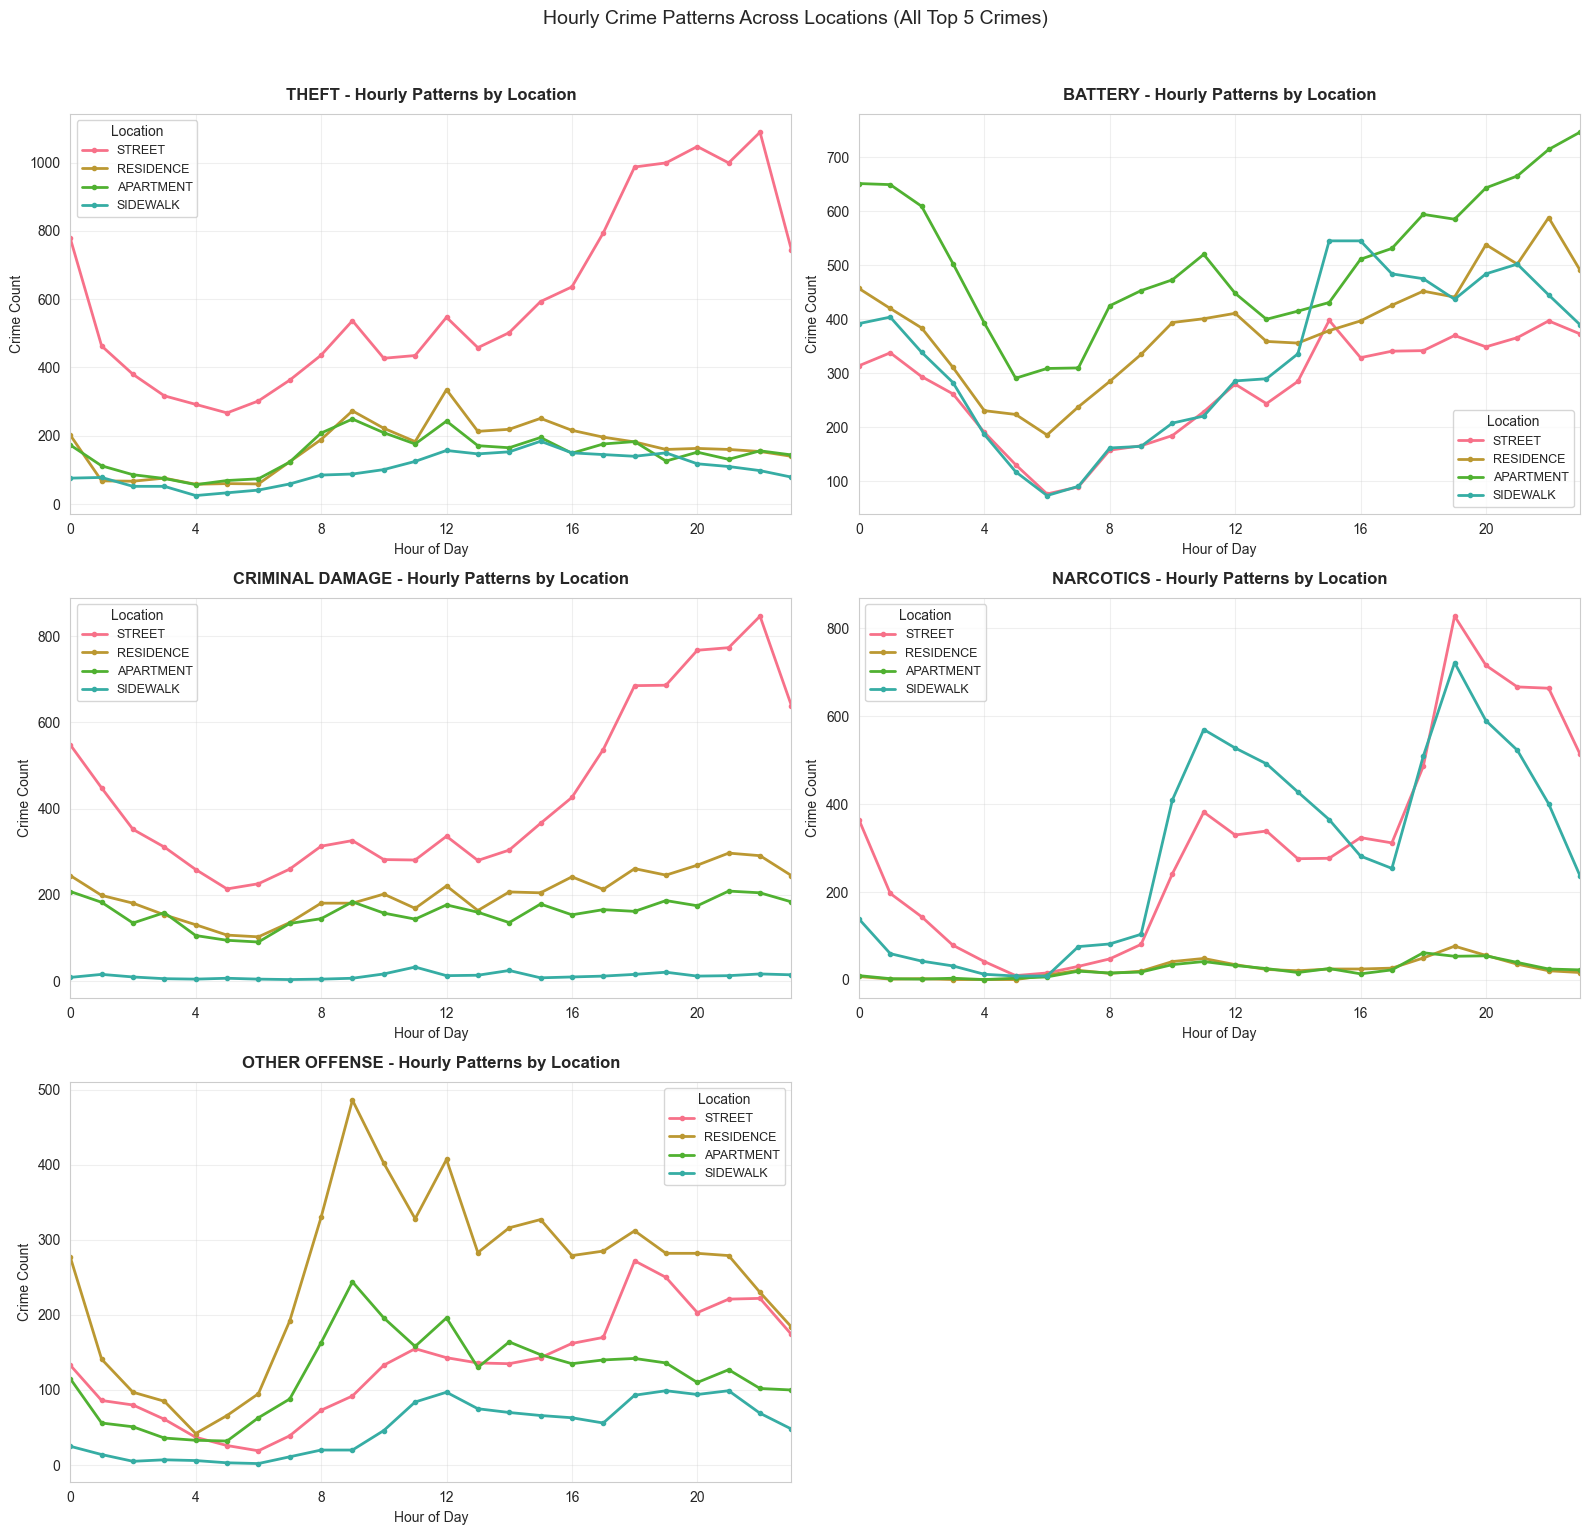

In [26]:
top_crimes_all = ['THEFT', 'BATTERY', 'CRIMINAL DAMAGE', 'NARCOTICS', 'OTHER OFFENSE']
top_locations = data['Location Description'].value_counts().head(4).index.tolist()

filtered_data = data[
    data['Primary Type'].isin(top_crimes_all) &
    data['Location Description'].isin(top_locations)
]

location_hourly = filtered_data.groupby(
    ['Primary Type', 'Location Description', 'Hour']
).size().reset_index(name='Count')

fig, axes = plt.subplots(3, 2, figsize=(16, 15))  # 3 rows, 2 columns
axes = axes.flatten()

for idx, crime in enumerate(top_crimes_all):
    ax = axes[idx]

    crime_data = location_hourly[location_hourly['Primary Type'] == crime]

    for location in top_locations:
        loc_data = crime_data[crime_data['Location Description'] == location]
        if not loc_data.empty:
            ax.plot(loc_data['Hour'], loc_data['Count'],
                    label=location, linewidth=2, marker='o', markersize=3)

    ax.set_title(f'{crime} - Hourly Patterns by Location', fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Hour of Day', fontsize=10)
    ax.set_ylabel('Crime Count', fontsize=10)
    ax.legend(fontsize=9, title='Location', title_fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 23)
    ax.set_xticks(range(0, 24, 4))

if len(top_crimes_all) < 6:
    axes[-1].set_visible(False)

plt.suptitle('Hourly Crime Patterns Across Locations (All Top 5 Crimes)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

We get a very intersting, clear patterns. We can see street theft crimes dominate throught the day, but mostly at night, because criminals have more chances in the dark. Other interesting and non-negligable factor is that aparatment and residence theft is peaking at 12 o'clock, at that time most of the people are out. Statements concluded brings us to the fact that theft pretty much depends on the opportunity.

Battery is again very chaotic, so only interpretation I have is that it really depends on human interaction density.

Criminal demage is peaking at night, also could be attributed to dark.

Other offences are noisy and very hard to interpret.


To sum up, the table below highights our observations.

In [27]:
predictability_summary = pd.DataFrame({
    'Crime Type': ['THEFT', 'BATTERY', 'CRIMINAL DAMAGE', 'NARCOTICS', 'OTHER OFFENSE'],
    'Temporal Pattern': ['Strong (3-6 PM)', 'Weak/Variable', 'Perfect (10 PM)', 'Perfect (7 PM)', 'Weak (Noon)'],
    'Spatial Pattern': ['Diffuse', 'Diffuse', 'Concentrated', 'Concentrated', 'Diffuse'],
    'Key Driver': ['Opportunity', 'Human Density', 'Darkness', 'Enforcement', 'Administrative'],
    'Predictability Score': ['High', 'Low', 'Very High', 'High (Artifactual)', 'Low'],
    'Recommended Features': ['Hour + Location + Season', 'Hour×Season + Area_Density', 'HOUR (22)', 'HOUR (19) + Street_Flag', 'Consider excluding']
})

print(predictability_summary.to_string(index=False))

     Crime Type Temporal Pattern Spatial Pattern     Key Driver Predictability Score       Recommended Features
          THEFT  Strong (3-6 PM)         Diffuse    Opportunity                 High   Hour + Location + Season
        BATTERY    Weak/Variable         Diffuse  Human Density                  Low Hour×Season + Area_Density
CRIMINAL DAMAGE  Perfect (10 PM)    Concentrated       Darkness            Very High                  HOUR (22)
      NARCOTICS   Perfect (7 PM)    Concentrated    Enforcement   High (Artifactual)    HOUR (19) + Street_Flag
  OTHER OFFENSE      Weak (Noon)         Diffuse Administrative                  Low         Consider excluding


To sum up, everything that has been stated before, there is structure in the data. Crime in the city is not random. It follows a fairly stable daily rhythm.

The clearest pattern is the relationship between time location signal. Across seasons, the city runs on the same daily routine (people wake up, commute, return home at similar hours, etc.) and crime moves with those patterns. These cycles show up again and again, which suggests that a lot of the signal is already tied to time.

Seasonality mostly affects volume, not structure. Summer brings more crime, especially on the streets, but it does not change when crime happens. Apartment and residence crimes stay mostly stable throughout the year. Hence, summer acts more like a season where more crimes appear to happen.

Arrest patterns point in the same direction. Lower arrest rates on summer nights line up with predictable spikes in crime volume, which looks more like capacity limits than random enforcement failure.

During the analysis outlier was detected and excluded from the analysis, this was narcotics.

### Narcotics

The analysis brought us to a conclusion, that the crime about narcotics, almost
always included an arrest. This appeared as an anomaly from the beginning
and finished with the point that this crime type was not about criminal activity,
rather more like police patroling. This would ruin the overall answer to the question.


This also makes it easier to separate signal from noise. Narcotics stands out as enforcement driven rather than behavior driven, since the crime only appears in the data when police find it. That makes it a weak target for prediction here, and removing it helps clarify the rest of the patterns.

What remains is data that reflects stable, mostly repeatable human behavior. There is enough structure to justify prediction, but only in context. Time by itself is weak, location by itself is weak, and crime type by itself is weak, the signal appears when they are combined.